In [12]:

import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Data source import complete.


# What is Pneumonia?
**Pneumonia is an inflammatory condition of the lung affecting primarily the small air sacs known as alveoli.Symptoms typically include some combination of productive or dry cough, chest pain, fever and difficulty breathing. The severity of the condition is variable. Pneumonia is usually caused by infection with viruses or bacteria and less commonly by other microorganisms, certain medications or conditions such as autoimmune diseases.Risk factors include cystic fibrosis, chronic obstructive pulmonary disease (COPD), asthma, diabetes, heart failure, a history of smoking, a poor ability to cough such as following a stroke and a weak immune system. Diagnosis is often based on symptoms and physical examination. Chest X-ray, blood tests, and culture of the sputum may help confirm the diagnosis.The disease may be classified by where it was acquired, such as community- or hospital-acquired or healthcare-associated pneumonia.**
![image.png](attachment:image.png)

In [6]:
# Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

import tensorflow as tf
from tensorflow import tensorflow.keras as keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Description of the Pneumonia Dataset
**The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal).
Chest X-ray images (anterior-posterior) were selected from retrospective cohorts of pediatric patients of one to five years old from Guangzhou Women and Children’s Medical Center, Guangzhou. All chest X-ray imaging was performed as part of patients’ routine clinical care.
For the analysis of chest x-ray images, all chest radiographs were initially screened for quality control by removing all low quality or unreadable scans. The diagnoses for the images were then graded by two expert physicians before being cleared for training the AI system. In order to account for any grading errors, the evaluation set was also checked by a third expert.**

In [15]:
train_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/train'
test_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/test'
val_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/val'


labels = ['PNEUMONIA', 'NORMAL']
img_size = 150

def get_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_arr is not None:  # Check if image loaded successfully
                    resized_arr = cv2.resize(img_arr, (img_size, img_size))
                    data.append([resized_arr, class_num])
                else:
                    print(f"Warning: Could not load image {img_path}")
            except Exception as e:
                print(f"Error processing image {img_path}: {e}")
    return np.array(data, dtype=object) # Use dtype=object to handle potential inconsistencies


# Load data
train = get_data(train_dir)
test = get_data(test_dir)
val = get_data(val_dir)



x_train = []
y_train = []
x_val = []
y_val = []
x_test = []
y_test = []

for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)

for feature, label in val:
    x_val.append(feature)
    y_val.append(label)

# Normalize and reshape the data
x_train = np.array(x_train) / 255
x_val = np.array(x_val) / 255
x_test = np.array(x_test) / 255

x_train = x_train.reshape(-1, img_size, img_size, 1)
y_train = np.array(y_train)

x_val = x_val.reshape(-1, img_size, img_size, 1)
y_val = np.array(y_val)

x_test = x_test.reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

# Data Augmentation
**In order to avoid overfitting problem, we need to expand artificially our dataset. We can make your existing dataset even larger. The idea is to alter the training data with small transformations to reproduce the variations.
Approaches that alter the training data in ways that change the array representation while keeping the label the same are known as data augmentation techniques. Some popular augmentations people use are grayscales, horizontal flips, vertical flips, random crops, color jitters, translations, rotations, and much more.
By applying just a couple of these transformations to our training data, we can easily double or triple the number of training examples and create a very robust model.**

In [ ]:
import numpy as np
import tensorflow as tf

# ---------- CONFIG ----------
try:
    IMG_SIZE
except NameError:
    IMG_SIZE = 224

# ---------- ARRAY STANDARDIZATION ----------
def _ensure_4d(arr):
    # Convert (N,H,W) -> (N,H,W,1)
    if arr.ndim == 3:
        arr = arr[..., np.newaxis]
    return arr

def _to_rgb(arr):
    # Make last channel 3
    if arr.shape[-1] == 1:
        arr = np.repeat(arr, 3, axis=-1)
    return arr

def _resize(arr, size):
    # Resize all images to (size,size)
    ds = tf.data.Dataset.from_tensor_slices(arr).map(
        lambda x: tf.image.resize(x, (size, size)),
        num_parallel_calls=tf.data.AUTOTUNE
    ).batch(64).prefetch(tf.data.AUTOTUNE)
    out = np.concatenate([b.numpy() for b in ds], axis=0)
    return out

def standardize_images(x, size):
    x = _ensure_4d(x)
    x = _to_rgb(x)
    x = _resize(x, size)
    return x

# If using arrays with ImageDataGenerator.flow(...), make sure shapes fit the model:
try:
    x_train  # noqa
    y_train  # noqa
    x_val    # noqa
    y_val    # noqa
    USING_ARRAY_FLOW = True
except NameError:
    USING_ARRAY_FLOW = False

if USING_ARRAY_FLOW:
    x_train = standardize_images(x_train, IMG_SIZE)
    x_val   = standardize_images(x_val, IMG_SIZE)

# ---------- LABEL / LOSS COMPAT ----------
# If y are integer class ids -> use sparse_categorical_crossentropy
def _is_integer_labels(y):
    return (y.ndim == 1) or (y.ndim == 2 and y.shape[-1] == 1)

try:
    current_loss = model.loss
except Exception:
    current_loss = None

if USING_ARRAY_FLOW:
    if _is_integer_labels(y_train):
        desired_loss = 'sparse_categorical_crossentropy'
    else:
        desired_loss = 'categorical_crossentropy'
else:
    # Generators typically use one-hot when class_mode='categorical', else sparse for 'sparse'
    desired_loss = current_loss or 'categorical_crossentropy'

if current_loss != desired_loss:
    # Re-compile model with correct loss
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss=desired_loss,
                  metrics=['accuracy'])
    print("Recompiled model with loss =", desired_loss)

# ---------- GENERATOR GUARD ----------
# If user plans to use ImageDataGenerator.flow(...), disable extra preprocess to avoid double-normalization
try:
    datagen  # noqa
    from tensorflow.keras.applications.densenet import preprocess_input as _dn_pre
    if hasattr(datagen, 'preprocessing_function') and datagen.preprocessing_function is not None:
        print("NOTE: Removing datagen.preprocessing_function to avoid double pre-processing (handled in model).")
        datagen.preprocessing_function = None
except Exception:
    pass

# Final input spec for sanity
print("Input ready. Expecting images of shape: (N, %d, %d, 3)" % (IMG_SIZE, IMG_SIZE))


In [16]:
datagen = ImageDataGenerator(
        featurewise_center=False,
        samplewise_center=False,
        featurewise_std_normalization=False,
        samplewise_std_normalization=False,
        zca_whitening=False,
        rotation_range = 30,
        zoom_range = 0.2,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip = True,
        vertical_flip=False)

datagen.fit(x_train)

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121

try:
    IMG_SIZE
except NameError:
    IMG_SIZE = 224

# number of classes inference
try:
    num_classes
except NameError:
    _nc = None
    for _cand in ['train_generator', 'train_gen', 'train_data', 'train_it']:
        try:
            _nc = len(eval(_cand).class_indices)
            break
        except Exception:
            pass
    if _nc is None:
        try:
            _nc = int(y_train.max()) + 1 if len(getattr(y_train, 'shape', [])) == 1 else y_train.shape[-1]
        except Exception:
            _nc = 2
    num_classes = int(_nc)

base = DenseNet121(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 38, 38, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 38, 38, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 19, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ last_conv_layer (Conv2D)        │ (None, 19, 19, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 19, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 19, 19, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       819,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 1,246,401 (4.75 MB)

 Trainable params: 1,245,313 (4.75 MB)

 Non-trainable params: 1,088 (4.25 KB)

**The data seems imbalanced . To increase the no. of training examples, we will use data augmentation**
**We perform a grayscale normalization to reduce the effect of illumination's differences.Moreover the CNN converges faster on [0..1] data than on [0..255].**

In [18]:
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy', patience = 2, verbose=1, factor=0.3, min_lr=0.000001)

history = model.fit(datagen.flow(x_train, y_train, batch_size = 32),
                    epochs = 15,
                    validation_data = datagen.flow(x_val, y_val),
                    callbacks = [learning_rate_reduction])

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


163/163 ━━━━━━━━━━━━━━━━━━━━ 25s 79ms/step - accuracy: 0.8105 - loss: 1.7435 - val_accuracy: 0.5000 - val_loss: 17.4008 - learning_rate: 0.0010
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.8944 - loss: 0.2643 - val_accuracy: 0.5000 - val_loss: 32.9726 - learning_rate: 0.0010
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9167 - loss: 0.2294
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.9167 - loss: 0.2294 - val_accuracy: 0.5000 - val_loss: 25.8418 - learning_rate: 0.0010
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.9497 - loss: 0.1534 - val_accuracy: 0.5000 - val_loss: 22.0058 - learning_rate: 3.0000e-04
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.9472 - loss: 0.1409
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
163/163 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.9472 - loss: 0.

In [19]:
# Standard Evaluation
print("Loss of the model is - " , model.evaluate(x_test,y_test)[0])
print("Accuracy of the model is - " , model.evaluate(x_test,y_test)[1]*100 , "%")

# Monte Carlo prediction function
def mc_predict(model, x, T=100):
    predictions = np.zeros((T, x.shape[0]))
    for i in range(T):
        preds = model(x, training=True)
        predictions[i, :] = preds.numpy().flatten()

    # Calculate mean and variance
    mean_predictions = np.mean(predictions, axis=0)
    uncertainty = np.var(predictions, axis=0)

    return mean_predictions, uncertainty

mc_predictions, mc_uncertainty = mc_predict(model, x_test)

# Convert probabilities to class labels
mc_predictions_classes = (mc_predictions > 0.5).astype(int)

# Print classification report
print("\nClassification Report (with Monte Carlo Dropout):")
print(classification_report(y_test, mc_predictions_classes, target_names=['Pneumonia (Class 0)', 'Normal (Class 1)']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8665 - loss: 0.2820
Loss of the model is -  0.26360949873924255
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8665 - loss: 0.2820
Accuracy of the model is -  88.14102411270142 %

Classification Report (with Monte Carlo Dropout):
                     precision    recall  f1-score   support

Pneumonia (Class 0)       0.87      0.98      0.92       390
   Normal (Class 1)       0.96      0.75      0.84       234

           accuracy                           0.90       624
          macro avg       0.92      0.87      0.88       624
       weighted avg       0.90      0.90      0.89       624



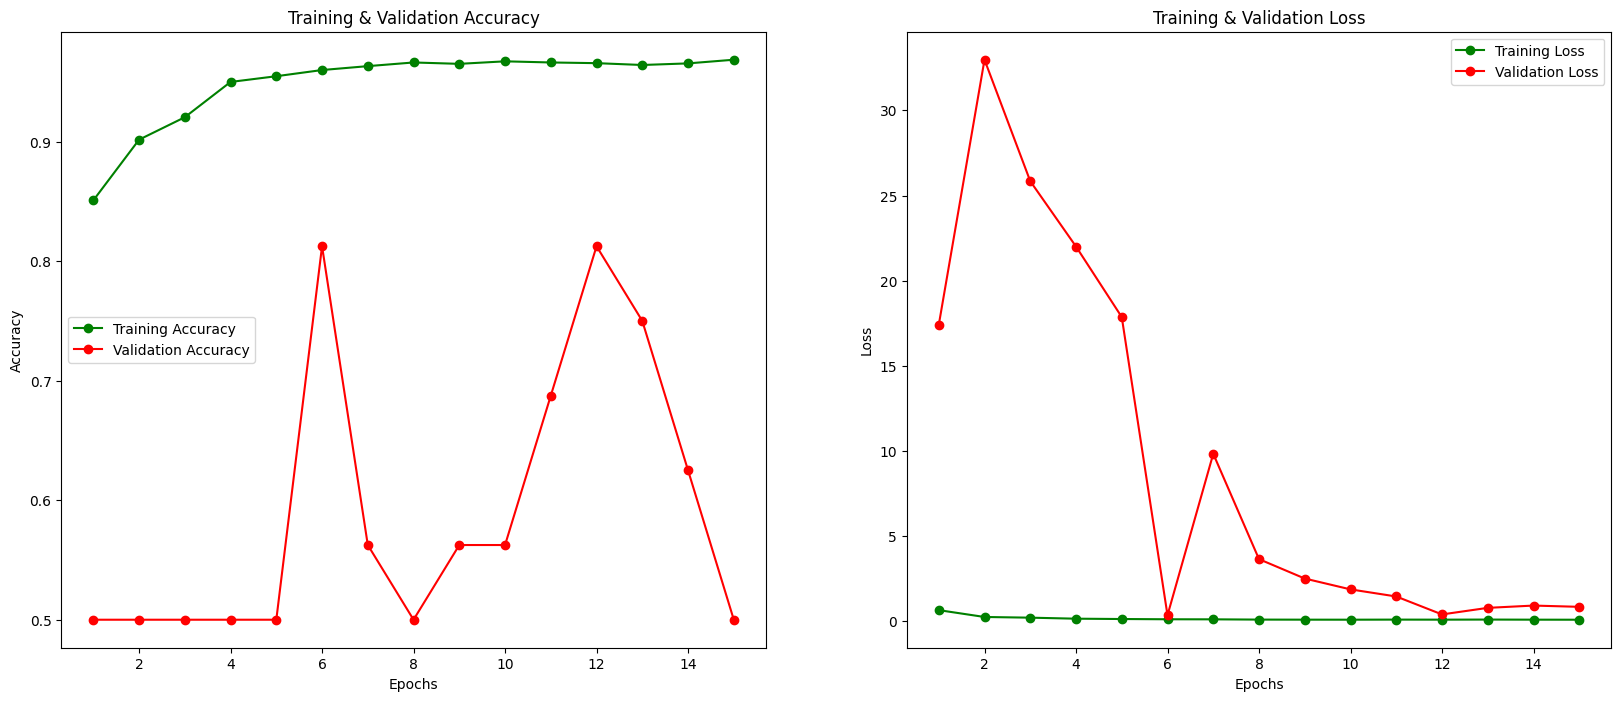

In [25]:
# Plotting the training and validation accuracy & loss
epochs = range(1, len(history.history['accuracy']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# Plot Training & Validation Accuracy
ax[0].plot(epochs, history.history['accuracy'], 'g-o', label='Training Accuracy')
ax[0].plot(epochs, history.history['val_accuracy'], 'r-o', label='Validation Accuracy')
ax[0].set_title('Training & Validation Accuracy')
ax[0].legend()
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")

# Plot Training & Validation Loss
ax[1].plot(epochs, history.history['loss'], 'g-o', label='Training Loss')
ax[1].plot(epochs, history.history['val_loss'], 'r-o', label='Validation Loss')
ax[1].set_title('Training & Validation Loss')
ax[1].legend()
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Loss")

plt.show()

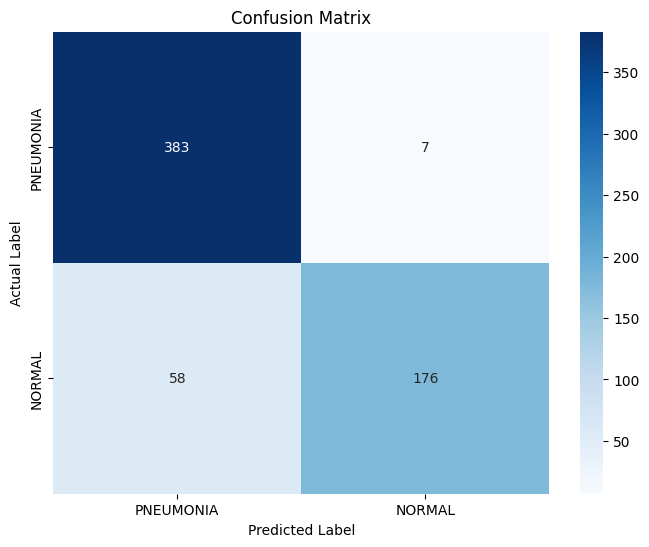

In [26]:
cm = confusion_matrix(y_test, mc_predictions_classes)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_254']
Received: inputs=Tensor(shape=(1, 150, 150, 1))
  warnings.warn(msg)
/tmp/ipython-input-2778749165.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = plt.cm.get_cmap("jet")


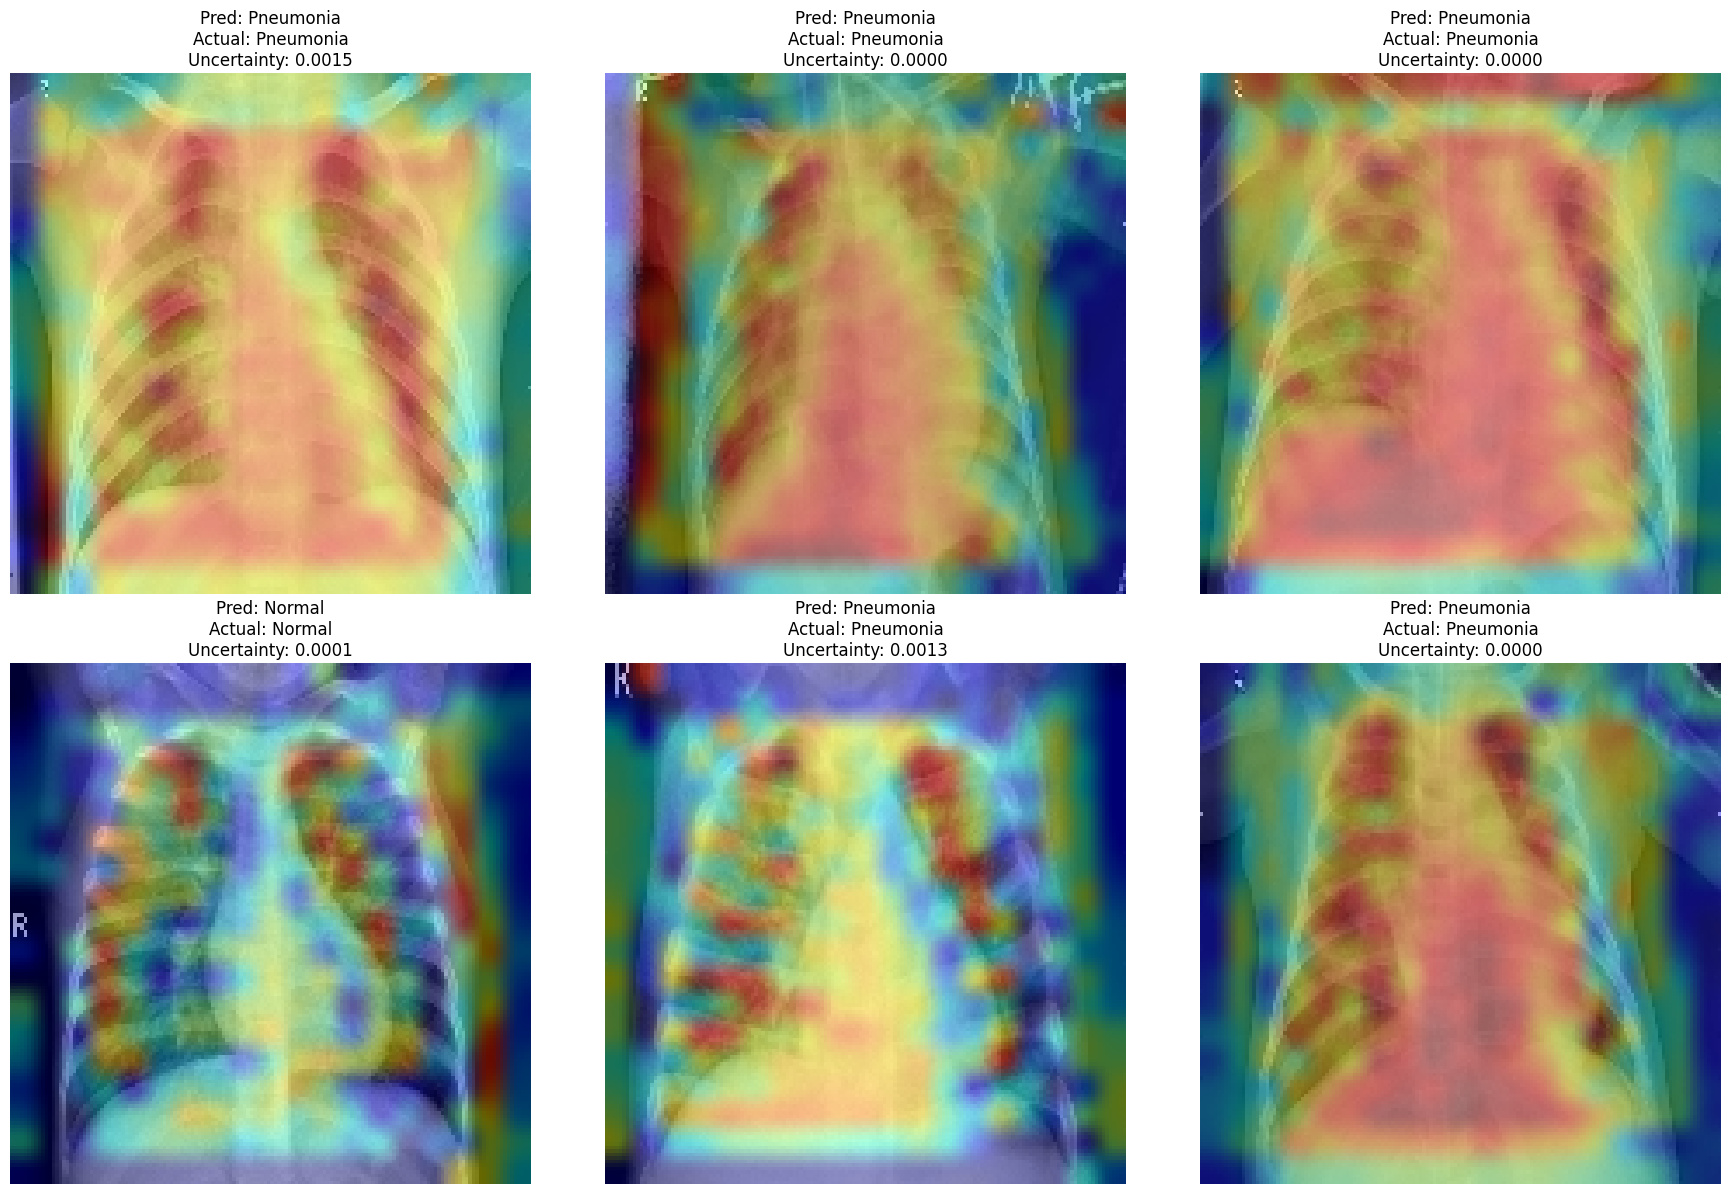

In [40]:

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[0]
    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def superimpose_gradcam(img, heatmap, alpha=0.4):
    heatmap = np.uint8(255 * heatmap)
    jet = plt.cm.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    stacked_img = np.stack((img,) * 3, axis=-1)
    jet_heatmap_img = tf.keras.utils.array_to_img(jet_heatmap)
    jet_heatmap_img = jet_heatmap_img.resize((stacked_img.shape[1], stacked_img.shape[0]))
    jet_heatmap_array = tf.keras.utils.img_to_array(jet_heatmap_img)
    superimposed_img = jet_heatmap_array * alpha + stacked_img * 255 * (1 - alpha)
    return tf.keras.utils.array_to_img(superimposed_img)

num_images_to_show = 6
last_conv_layer_name = "last_conv_layer"

plt.figure(figsize=(18, 12))
for i, index in enumerate(np.random.choice(len(x_test), num_images_to_show, replace=False)):
    img_array = x_test[index]

    heatmap = make_gradcam_heatmap(np.expand_dims(img_array, axis=0), model, last_conv_layer_name)
    superimposed_img = superimpose_gradcam(img_array.squeeze(), heatmap)

    pred_label = "Pneumonia" if mc_predictions_classes[index] == 0 else "Normal"
    actual_label = "Pneumonia" if y_test[index] == 0 else "Normal"
    uncertainty_val = mc_uncertainty[index]

    ax = plt.subplot(2, num_images_to_show // 2, i + 1)
    plt.imshow(superimposed_img)
    plt.title(f"Pred: {pred_label}\nActual: {actual_label}\nUncertainty: {uncertainty_val:.4f}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.densenet import preprocess_input

try:
    IMG_SIZE
except NameError:
    IMG_SIZE = 224

def ensure_4d_rgb(arr):
    arr = np.asarray(arr)
    if arr.ndim == 3:  # (N,H,W) -> (N,H,W,1)
        arr = arr[..., np.newaxis]
    if arr.shape[-1] == 1:  # gray -> rgb
        arr = np.repeat(arr, 3, axis=-1)
    # resize to IMG_SIZE
    ds = tf.data.Dataset.from_tensor_slices(arr).map(
        lambda x: tf.image.resize(tf.cast(x, tf.float32), (IMG_SIZE, IMG_SIZE)),
        num_parallel_calls=tf.data.AUTOTUNE
    ).batch(64).prefetch(tf.data.AUTOTUNE)
    arr = np.concatenate([b.numpy() for b in ds], axis=0)
    return arr

def build_array_generators(x_tr, y_tr, x_va, y_va, batch_size=32):
    x_tr = ensure_4d_rgb(x_tr)
    x_va = ensure_4d_rgb(x_va)
    train_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow(x_tr, y_tr, batch_size=batch_size)
    val_gen   = ImageDataGenerator(preprocessing_function=preprocess_input).flow(x_va, y_va, batch_size=batch_size, shuffle=False)
    return train_gen, val_gen

def choose_loss(y):
    # integer labels -> sparse; one-hot -> categorical
    y = np.asarray(y)
    if y.ndim == 1 or (y.ndim == 2 and y.shape[-1] == 1):
        return 'sparse_categorical_crossentropy'
    return 'categorical_crossentropy'

# Build training and validation iterators robustly
train_iterator = None
val_iterator = None

# Case A: user already has directory generators
for tg_name in ['train_generator', 'train_gen', 'train_data', 'train_it']:
    if tg_name in globals():
        train_iterator = globals()[tg_name]
        break
for vg_name in ['val_generator', 'validation_generator', 'valid_generator', 'val_gen']:
    if vg_name in globals():
        val_iterator = globals()[vg_name]
        break

# Case B: arrays + datagen or arrays only
if train_iterator is None and 'x_train' in globals() and 'y_train' in globals() and 'x_val' in globals() and 'y_val' in globals():
    batch_size = 32
    try:
        batch_size = int(batch_size)
    except Exception:
        batch_size = 32
    train_iterator, val_iterator = build_array_generators(x_train, y_train, x_val, y_val, batch_size=batch_size)
    # Re-compile with correct loss for array labels
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss=choose_loss(y_train),
                  metrics=['accuracy'])

# Sanity checks
if train_iterator is None:
    raise RuntimeError("Could not find training data. Provide train_generator or x_train/y_train.")
if val_iterator is None:
    # Try to infer a validation iterator from the same datagen (optional)
    if 'x_val' in globals() and 'y_val' in globals():
        _, val_iterator = build_array_generators(x_train, y_train, x_val, y_val, batch_size=32)
    else:
        raise RuntimeError("Could not find validation data. Provide val_generator or x_val/y_val.")

# Default train settings if not defined
try:
    EPOCHS
except NameError:
    EPOCHS = 15
try:
    BATCH_SIZE
except NameError:
    BATCH_SIZE = 32

print("Training with: IMG_SIZE=", IMG_SIZE, "| epochs=", EPOCHS, "| batch_size=", BATCH_SIZE)
print("First batch shape:", next(iter(train_iterator))[0].shape)

# Optional callback
try:
    callbacks
except NameError:
    callbacks = []

history = model.fit(
    train_iterator,
    epochs=EPOCHS,
    validation_data=val_iterator,
    callbacks=callbacks
)
print("Done.")
